# Model Comparison — USGS Streamflow (+ Precipitation)

Trains four spatiotemporal architectures on the Delaware River basin gauges and compares test MAE/MSE.
Precipitation is included as an exogenous covariate (`u`) alongside the streamflow target.

| Model | Temporal encoder | Spatial encoder |
|---|---|---|
| **DCRNN** | GRU | Diffusion convolution (ChebNet) |
| **GRUGCNModel** | GRU | Graph convolution (GCN) |
| **GraphWaveNet** | Dilated TCN | Adaptive adjacency GCN |
| **TransformerModel** | Self-attention | None (flat node axis) |

Settings: `window=7` days in → `horizon=3` days out, 31 gauges, daily discharge.


## How this notebook works

### What the model does

**Input:** past `window=7` days of discharge **and precipitation** at **all 31 gauges simultaneously**, plus the river graph (which encodes which gauges are upstream of which).  
**Output:** next `horizon=3` days of discharge at **all 31 gauges simultaneously**.

Precipitation enters as an exogenous covariate `u` (shape `(B, window, N, 1)`), scaled independently of the streamflow target.

The `batch_size=16` means 16 **time windows** per gradient step. Every batch always includes all 31 gauges.

### Train / Val / Test split — by time, not by gauge

```
|─────── train (70%) ──────|── val (10%) ──|── test (20%) ──|
Oct 2021                                   Jul 19, 2022    Sep 30, 2022
```

The model is trained on Oct 2021 → ~Jul 2022, validated on the next ~5 weeks, and tested on **Jul 19 – Sep 30** (summer low-flow / storm season).


## 1. Data setup (reused from usgs_streamflow_tsl.ipynb)

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from tsl.data import SpatioTemporalDataset, SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Predictor
from tsl.metrics.torch import MaskedMAE, MaskedMSE

pl.seed_everything(42)

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

# --- Target DataFrame ---
streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)

id_conversion = pd.read_csv(
    os.path.join(os.getcwd(), '../02_Generate_Graph_And_Data_Analysis/site_id_naming_reference.csv'),
    dtype={'site_id': str}
)

rename_map = id_conversion.set_index('site_id')['site_rename'].to_dict()

target = streamflow.rename(columns=rename_map)
target = target[sorted(target.columns, key=lambda x: int(x.replace('site', '')))]
target = target.ffill().bfill()

# --- Exogenous covariate: precipitation ---
precipitation = pd.read_csv(
    os.path.join(DATA_DIR, 'precipitation_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)
precipitation = precipitation.rename(columns=rename_map)
precipitation = precipitation[sorted(precipitation.columns, key=lambda x: int(x.replace('site', '')))]
precipitation = precipitation.ffill().bfill()

# Align to shared dates (in case the two CSVs differ by a day at the boundary)
common_idx    = target.index.intersection(precipitation.index)
target        = target.loc[common_idx]
precipitation = precipitation.loc[common_idx]
print(f'Aligned to {len(common_idx)} shared timesteps')

N_NODES = target.shape[1]
print(f'Target:        {target.shape}')
print(f'Precipitation: {precipitation.shape}')

# --- Connectivity ---
graph_edges_all = [
    ('site0','site2'),('site1','site2'),('site2','site6'),('site3','site6'),
    ('site4','site6'),('site5','site6'),('site6','site8'),('site7','site8'),
    ('site8','site9'),('site9','site11'),('site10','site11'),('site11','site13'),
    ('site12','site13'),('site13','site15'),('site14','site15'),('site15','site17'),
    ('site16','site17'),('site18','site21'),('site19','site20'),('site20','site21'),
    ('site21','site26'),('site22','site26'),('site23','site26'),('site24','site26'),
    ('site25','site26'),('site26','site27'),('site27','site30'),('site28','site29'),
    ('site29','site30'),('site30','site13'),
]
node_to_idx = {f'site{i}': i for i in range(31)}
src = [node_to_idx[u] for u, v in graph_edges_all]
dst = [node_to_idx[v] for u, v in graph_edges_all]
edge_index  = torch.tensor([src, dst], dtype=torch.long)
edge_weight = torch.ones(edge_index.shape[1], dtype=torch.float)
connectivity = (edge_index, edge_weight)

print(f'Graph: {N_NODES} nodes, {edge_index.shape[1]} edges')

[rank: 0] Seed set to 42


Aligned to 364 shared timesteps
Target:        (364, 31)
Precipitation: (364, 31)
Graph: 31 nodes, 30 edges


## 2. Shared dataset and datamodule factory

In [2]:
WINDOW  = 7
HORIZON = 3
BATCH   = 16

torch_dataset = SpatioTemporalDataset(
    target=target,
    connectivity=connectivity,
    window=WINDOW,
    horizon=HORIZON,
    stride=1,
)
# Reshape to (T, N, 1) and use pattern 't n f' so each batch yields u: (B, window, N, 1).
# With pattern 't n' the batch would be (B, window, N) — 3D — and DCRNN would misinterpret
# the node axis as a feature/channel axis, causing a shape mismatch in its linear layer.
precip_array = torch.tensor(
    precipitation.values[:, :, np.newaxis], dtype=torch.float32
)  # (T, N, 1)
torch_dataset.add_covariate('u', precip_array, pattern='t n f')

def make_dm():
    """Fresh DataModule with refitted scalers — call once per model run."""
    dm = SpatioTemporalDataModule(
        dataset=torch_dataset,
        scalers={
            'target': StandardScaler(axis=(0, 1)),
            'u':      StandardScaler(axis=(0, 1)),
        },
        splitter=TemporalSplitter(val_len=0.1, test_len=0.2),
        batch_size=BATCH,
        workers=4,
    )
    dm.setup()
    return dm

dm_check = make_dm()
batch = next(iter(dm_check.train_dataloader()))
print('Sample input x :', batch.input.x.shape)   # (B, window, N, 1)
print('Sample input u :', batch.input.u.shape)   # (B, window, N, 1)  — precipitation
print('Sample target y:', batch.y.shape)          # (B, horizon, N, 1)
print('Train / Val / Test batches:',
      len(dm_check.train_dataloader()),
      len(dm_check.val_dataloader()),
      len(dm_check.test_dataloader()))

/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_ration

Sample input x : torch.Size([16, 7, 31, 1])
Sample input u : torch.Size([16, 7, 31, 1])
Sample target y: torch.Size([16, 3, 31, 1])
Train / Val / Test batches: 15 2 5


## 3. Training helper + forecast collection

In [3]:
from pytorch_lightning.callbacks import ModelCheckpoint

def train_and_evaluate(model, name, max_epochs=30):
    """
    Train model, evaluate on test set, and collect forecasts.

    Returns
    -------
    metrics : dict
        test_mae, test_mse, model name, param count
    forecasts : dict
        y_true  : (n_test, N) — step-1 of horizon, inverse-scaled (m³/s)
        y_hat   : (n_test, N) — step-1 of horizon, inverse-scaled (m³/s)
        y_true_h: (n_test, horizon, N) — full horizon, inverse-scaled
        y_hat_h : (n_test, horizon, N) — full horizon, inverse-scaled
        dates   : DatetimeIndex aligned to the first predicted day
        dm      : the fitted DataModule (scaler lives here)
    """
    print(f'\n{"="*60}')
    print(f'  {name}')
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n_params:,}')
    print(f'{"="*60}')

    dm = make_dm()

    predictor = Predictor(
        model=model,
        optim_class=torch.optim.Adam,
        optim_kwargs={'lr': 1e-3},
        loss_fn=MaskedMAE(),
        metrics={'mae': MaskedMAE(), 'mse': MaskedMSE()},
        scale_target=True,
    )

    checkpoint_cb = ModelCheckpoint(
        monitor='val_mae',
        mode='min',
        save_top_k=1,
        filename=f'{name}-best',
    )

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='auto',
        devices=1,
        enable_progress_bar=True,
        logger=False,
        callbacks=[checkpoint_cb],
    )

    trainer.fit(predictor, datamodule=dm)
    print(f'  Best val_mae checkpoint: {checkpoint_cb.best_model_path}')

    # Load best weights before test / forecast collection
    predictor = Predictor.load_from_checkpoint(
        checkpoint_cb.best_model_path,
        model=model,
        optim_class=torch.optim.Adam,
        optim_kwargs={'lr': 1e-3},
        loss_fn=MaskedMAE(),
        metrics={'mae': MaskedMAE(), 'mse': MaskedMSE()},
        scale_target=True,
        weights_only=False,
    )

    test_metrics = trainer.test(predictor, datamodule=dm, verbose=False)

    # ── Collect raw predictions on the test set ──────────────────────────
    predictor.eval()
    y_true_list, y_hat_list = [], []

    with torch.no_grad():
        for batch in dm.test_dataloader():
            y_hat = predictor.predict_batch(batch, preprocess=False, postprocess=False)
            y_true_list.append(batch.y.cpu())
            y_hat_list.append(y_hat.cpu())

    # Stack → (n_test_samples, horizon, N) — keep as Tensors for inverse_transform
    y_true_all = torch.cat(y_true_list).squeeze(-1)
    y_hat_all  = torch.cat(y_hat_list).squeeze(-1)

    # batch.y comes out of the DataModule in original (m³/s) space — no inverse_transform needed.
    # y_hat from predict_batch(postprocess=False) is in scaled space — inverse_transform it.
    scaler = dm.scalers['target']
    n, h, n_nodes = y_true_all.shape
    y_true_inv = y_true_all.numpy()
    y_hat_inv  = scaler.inverse_transform(
        y_hat_all.reshape(-1, n_nodes)).reshape(n, h, n_nodes).numpy()

    # ── Align predictions to calendar dates ──────────────────────────────
    # For sample at dataset index k, the input window covers rows k … k+WINDOW-1,
    # so the first predicted timestep is row k + WINDOW in target.
    test_indices = dm.test_dataloader().dataset.indices   # integer positions in torch_dataset
    pred_dates   = target.index[[idx + WINDOW for idx in test_indices]]

    forecasts = {
        'y_true'  : y_true_inv[:, 0, :],   # (n_test, N)
        'y_hat'   : y_hat_inv[:, 0, :],    # (n_test, N)
        'y_true_h': y_true_inv,            # (n_test, horizon, N)
        'y_hat_h' : y_hat_inv,             # (n_test, horizon, N)
        'dates'   : pred_dates,
        'dm'      : dm,
    }

    test_metrics[0]['model']    = name
    test_metrics[0]['n_params'] = n_params
    return test_metrics[0], forecasts


## 4. Model A — DCRNN
Diffusion Convolutional Recurrent Neural Network.  
GRU cells with diffusion graph convolution as the spatial mixing step. Strong baseline for directed graphs.

In [4]:
from tsl.nn.models import DCRNNModel

dcrnn = DCRNNModel(
    input_size=1,
    exog_size=1,
    output_size=1,
    horizon=HORIZON,
    hidden_size=32,
    kernel_size=8,
    n_layers=2,
    dropout=0.1,
)

results_dcrnn, forecasts_dcrnn = train_and_evaluate(dcrnn, 'DCRNN')
save_path = os.path.join(FORECASTS_DIR, 'dcrnn_forecasts_rain_8hop.pt')
torch.save(forecasts_dcrnn, save_path)
print(f'DCRNN forecasts saved to: {save_path}')

/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/lp9617/.conda/envs/CEE520_env/lib/python3.13/s ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/lp9617/workspace/CEE520/CEE520-


  DCRNN
  Trainable parameters: 220,515


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Only args ['edge_weight', 'edge_index', 'u', 'x'] are forwarded to the model (DCRNNModel).
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can en

Training: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=30` reached.


  Best val_mae checkpoint: /home/lp9617/workspace/CEE520/CEE520-StreamflowGraphLearning/src/03_TorchSpatiotemporal/checkpoints/DCRNN-best-v12.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

Only args ['edge_weight', 'edge_index', 'u', 'x'] are forwarded to the model (DCRNNModel).
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


DCRNN forecasts saved to: /home/lp9617/workspace/CEE520/CEE520-StreamflowGraphLearning/data/forecast/dcrnn_forecasts_rain_8hop.pt


## 5. Model B — GRUGCNModel
GRU encoder followed by a GCN layer for spatial aggregation.  
Simpler than DCRNN — GRU and GCN are decoupled rather than interleaved.

In [5]:
from tsl.nn.models import GRUGCNModel

grugcn = GRUGCNModel(
    input_size=1,
    hidden_size=32,
    output_size=1,
    horizon=HORIZON,
    exog_size=1,
    enc_layers=2,
    gcn_layers=8,
)

results_grugcn, forecasts_grugcn = train_and_evaluate(grugcn, 'GRUGCNModel')
save_path = os.path.join(FORECASTS_DIR, 'grugcn_forecasts_rain_8hop.pt')
torch.save(forecasts_grugcn, save_path)
print(f'GRUGCNModel forecasts saved to: {save_path}')

/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/lp9617/.conda/envs/CEE520_env/lib/python3.13/s ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/lp9617/workspace/CEE520/CEE520-


  GRUGCNModel
  Trainable parameters: 20,451


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoade

Training: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=30` reached.


  Best val_mae checkpoint: /home/lp9617/workspace/CEE520/CEE520-StreamflowGraphLearning/src/03_TorchSpatiotemporal/checkpoints/GRUGCNModel-best-v6.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

Only args ['edge_weight', 'edge_index', 'u', 'x'] are forwarded to the model (GRUGCNModel).
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


GRUGCNModel forecasts saved to: /home/lp9617/workspace/CEE520/CEE520-StreamflowGraphLearning/data/forecast/grugcn_forecasts_rain_8hop.pt


## 6. Results comparison

In [14]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from tsl.data import SpatioTemporalDataset, SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Predictor
from tsl.metrics.torch import MaskedMAE, MaskedMSE

pl.seed_everything(42)

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

# --- Target DataFrame ---
streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)


# ── Load forecasts from disk ─────────────────────────────────────────────
# Use this block when restarting the kernel to skip retraining.
MODEL_FILES = {
    'DCRNN':       'dcrnn_forecasts_rain_8hop.pt',
    'GRUGCNModel': 'grugcn_forecasts_rain_8hop.pt',
}

all_forecasts = {}
all_results   = []

for name, fname in MODEL_FILES.items():
    fpath = os.path.join(FORECASTS_DIR, fname)
    if not os.path.exists(fpath):
        print(f'Missing: {fpath} — run the training cells first')
        continue
    fc = torch.load(fpath, weights_only=False)
    all_forecasts[name] = fc
    # Recompute MAE/MSE from saved arrays (original m³/s space)
    mae = float(np.abs(fc['y_true'] - fc['y_hat']).mean())
    mse = float(((fc['y_true'] - fc['y_hat']) ** 2).mean())
    all_results.append({'model': name, 'test_mae': mae, 'test_mse': mse, 'n_params': None})
    print(f'Loaded {name}  MAE={mae:.3f} m³/s  MSE={mse:.3f}')

df_results = pd.DataFrame(all_results).set_index('model')
df_results.columns = [c.replace('test_', '') for c in df_results.columns]
print()
print(df_results[['mae', 'mse', 'n_params']].to_string())

[rank: 0] Seed set to 42


Loaded DCRNN  MAE=2.294 m³/s  MSE=68.202
Loaded GRUGCNModel  MAE=1.867 m³/s  MSE=72.685

                  mae        mse n_params
model                                    
DCRNN        2.293701  68.201683     None
GRUGCNModel  1.866674  72.684990     None


/home/lp9617/.conda/envs/CEE520_env/lib/python3.13/site-packages/torch/serialization.py:2190: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  result = unpickler.load()


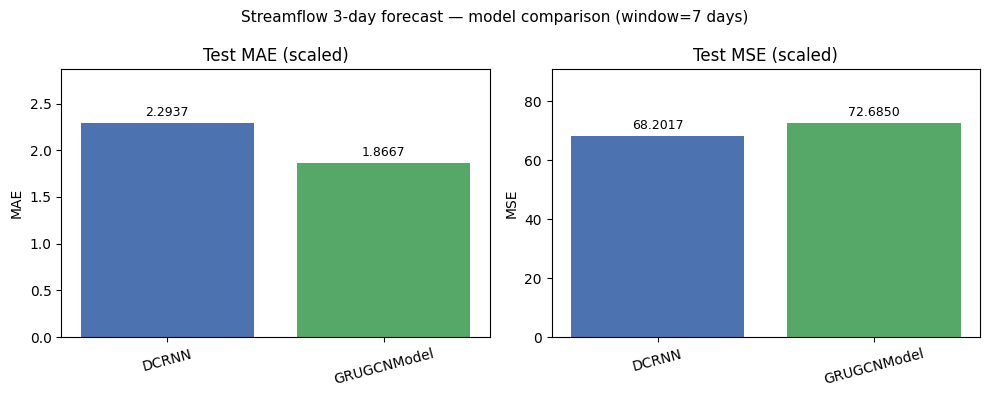

In [15]:
# ── MAE / MSE bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = df_results.index.tolist()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, metric in zip(axes, ['mae', 'mse']):
    bars = ax.bar(models, df_results[metric], color=colors)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(f'Test {metric.upper()} (scaled)')
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, df_results[metric].max() * 1.25)

plt.suptitle('Streamflow 3-day forecast — model comparison (window=7 days)', fontsize=11)
plt.tight_layout()
plt.show()

## 7. All-gauge forecast plots

For each model: a grid showing all 31 gauges. Each subplot has:
- **Grey** — observed discharge in the 30 days before the test period (context)
- **Black** — observed discharge during the test period (ground truth)
- **Coloured** — model forecast (step-1 of horizon, i.e. next-day prediction)

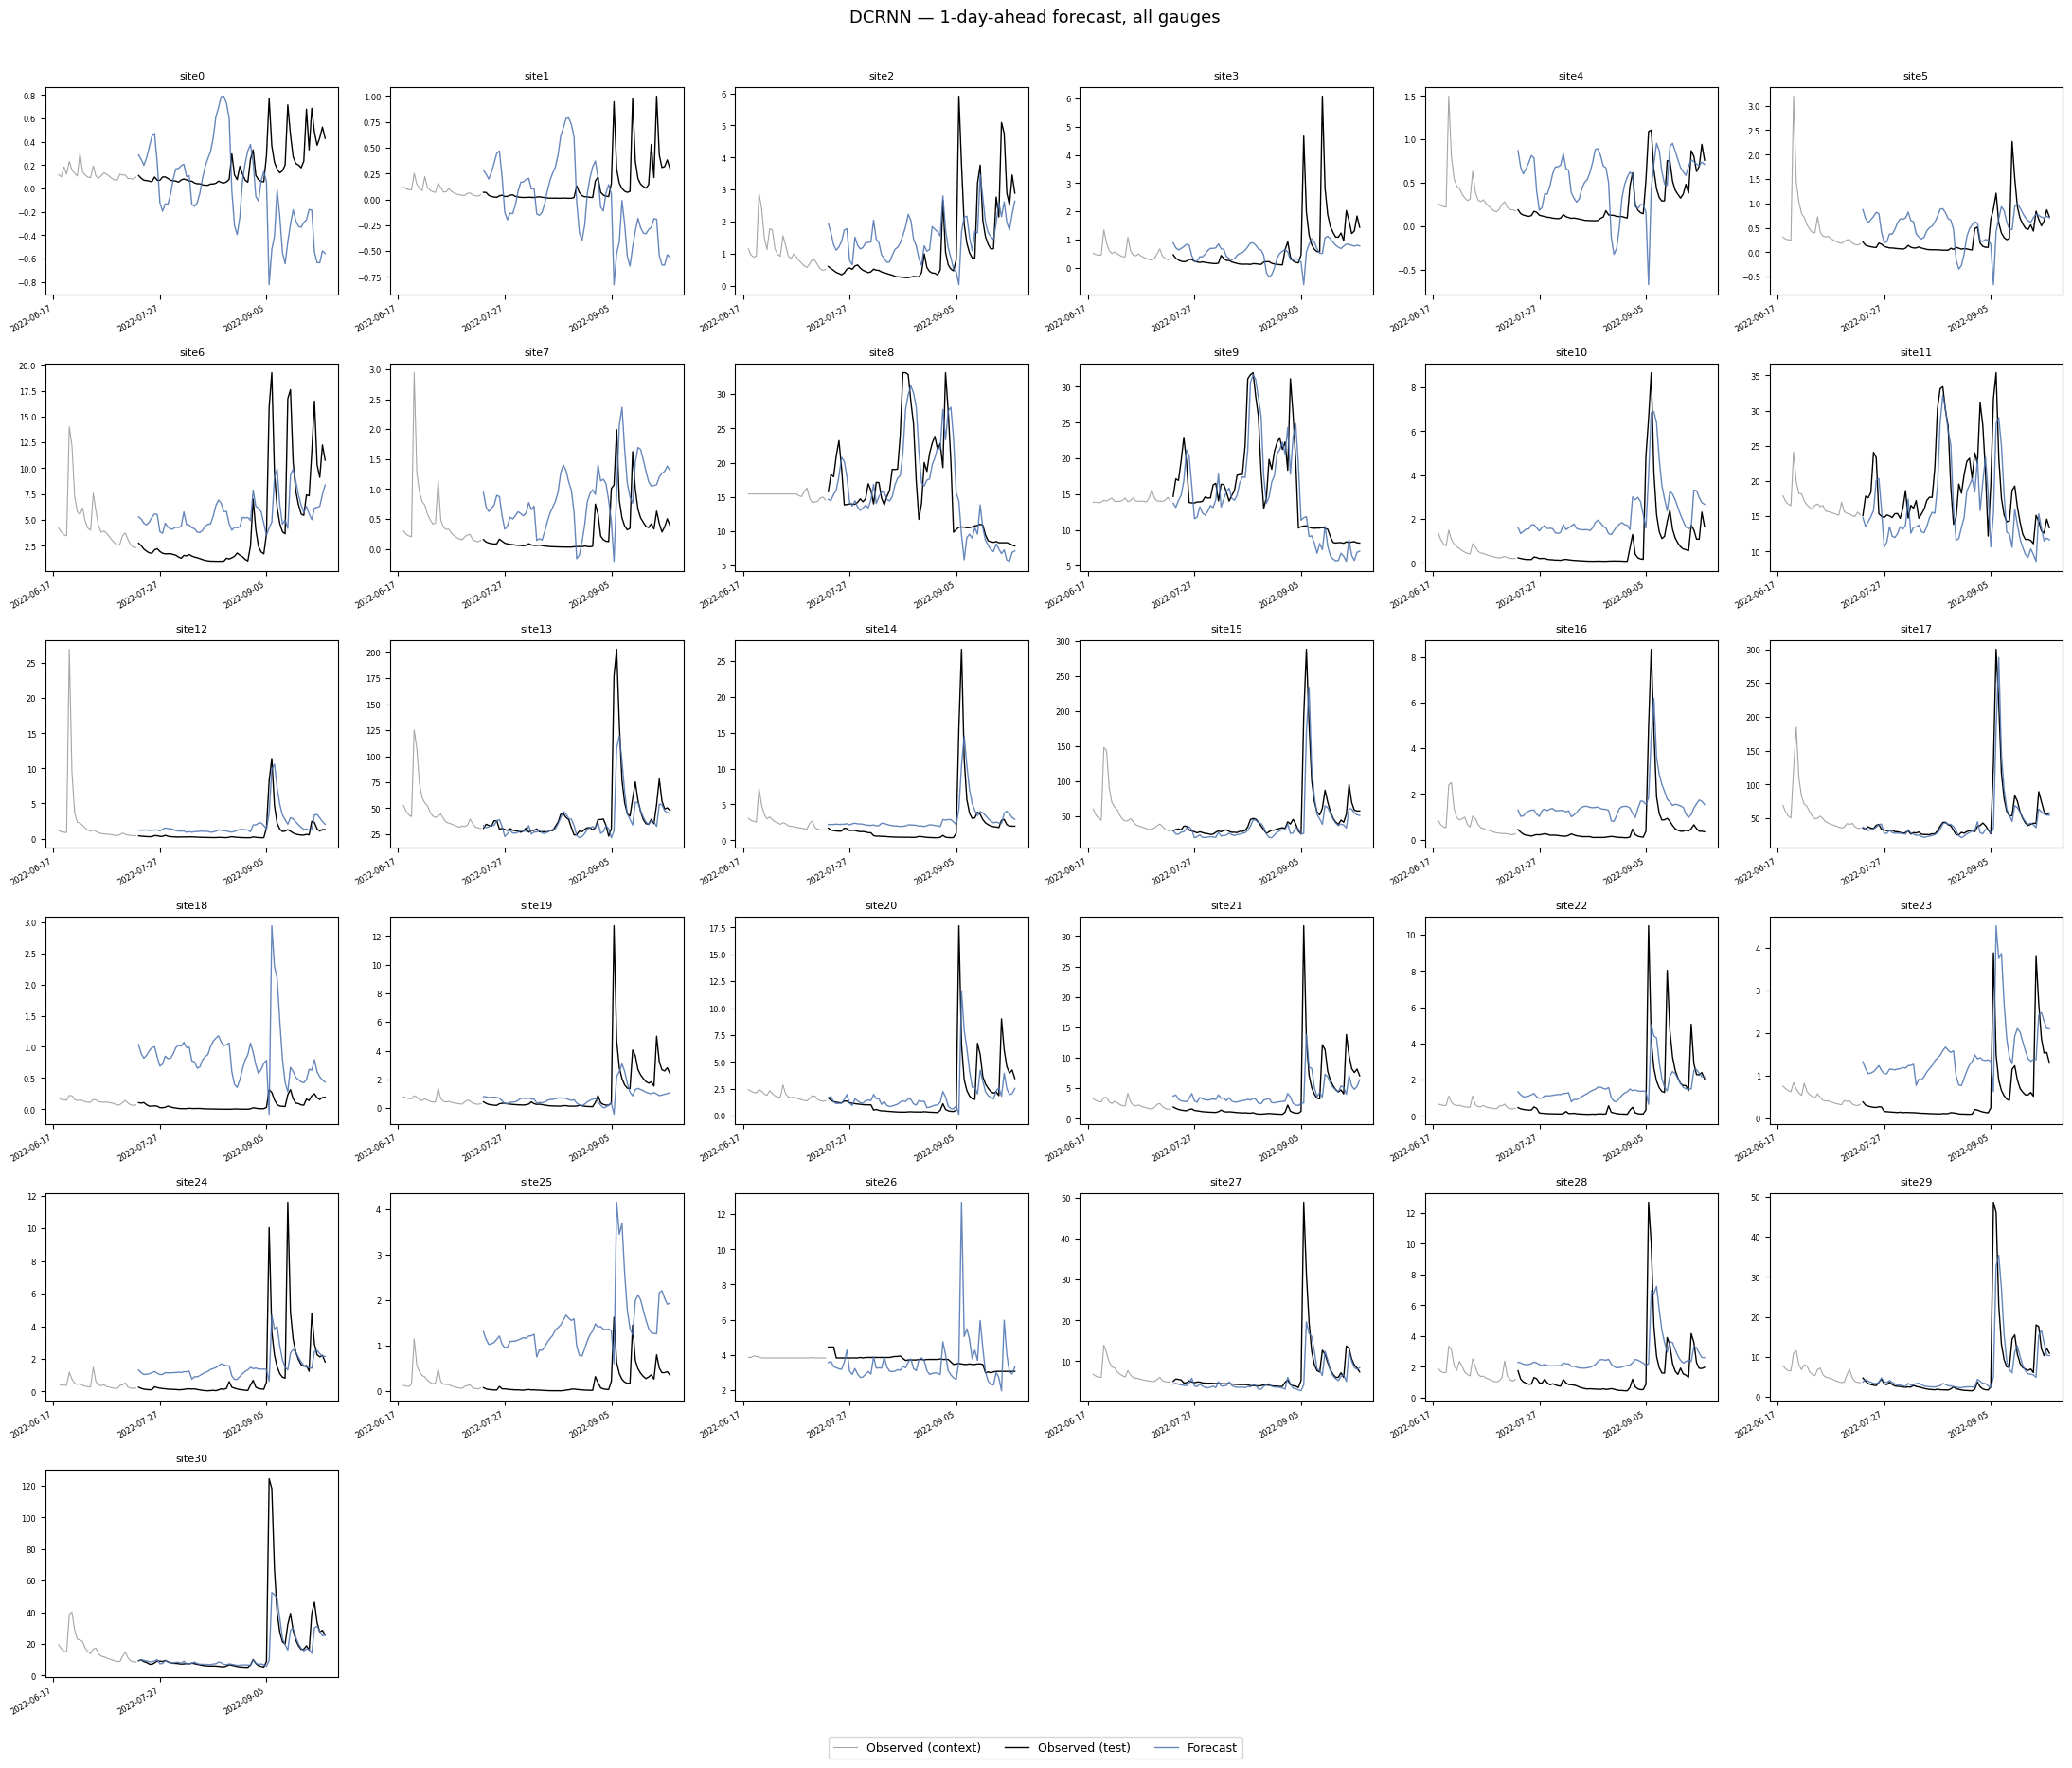

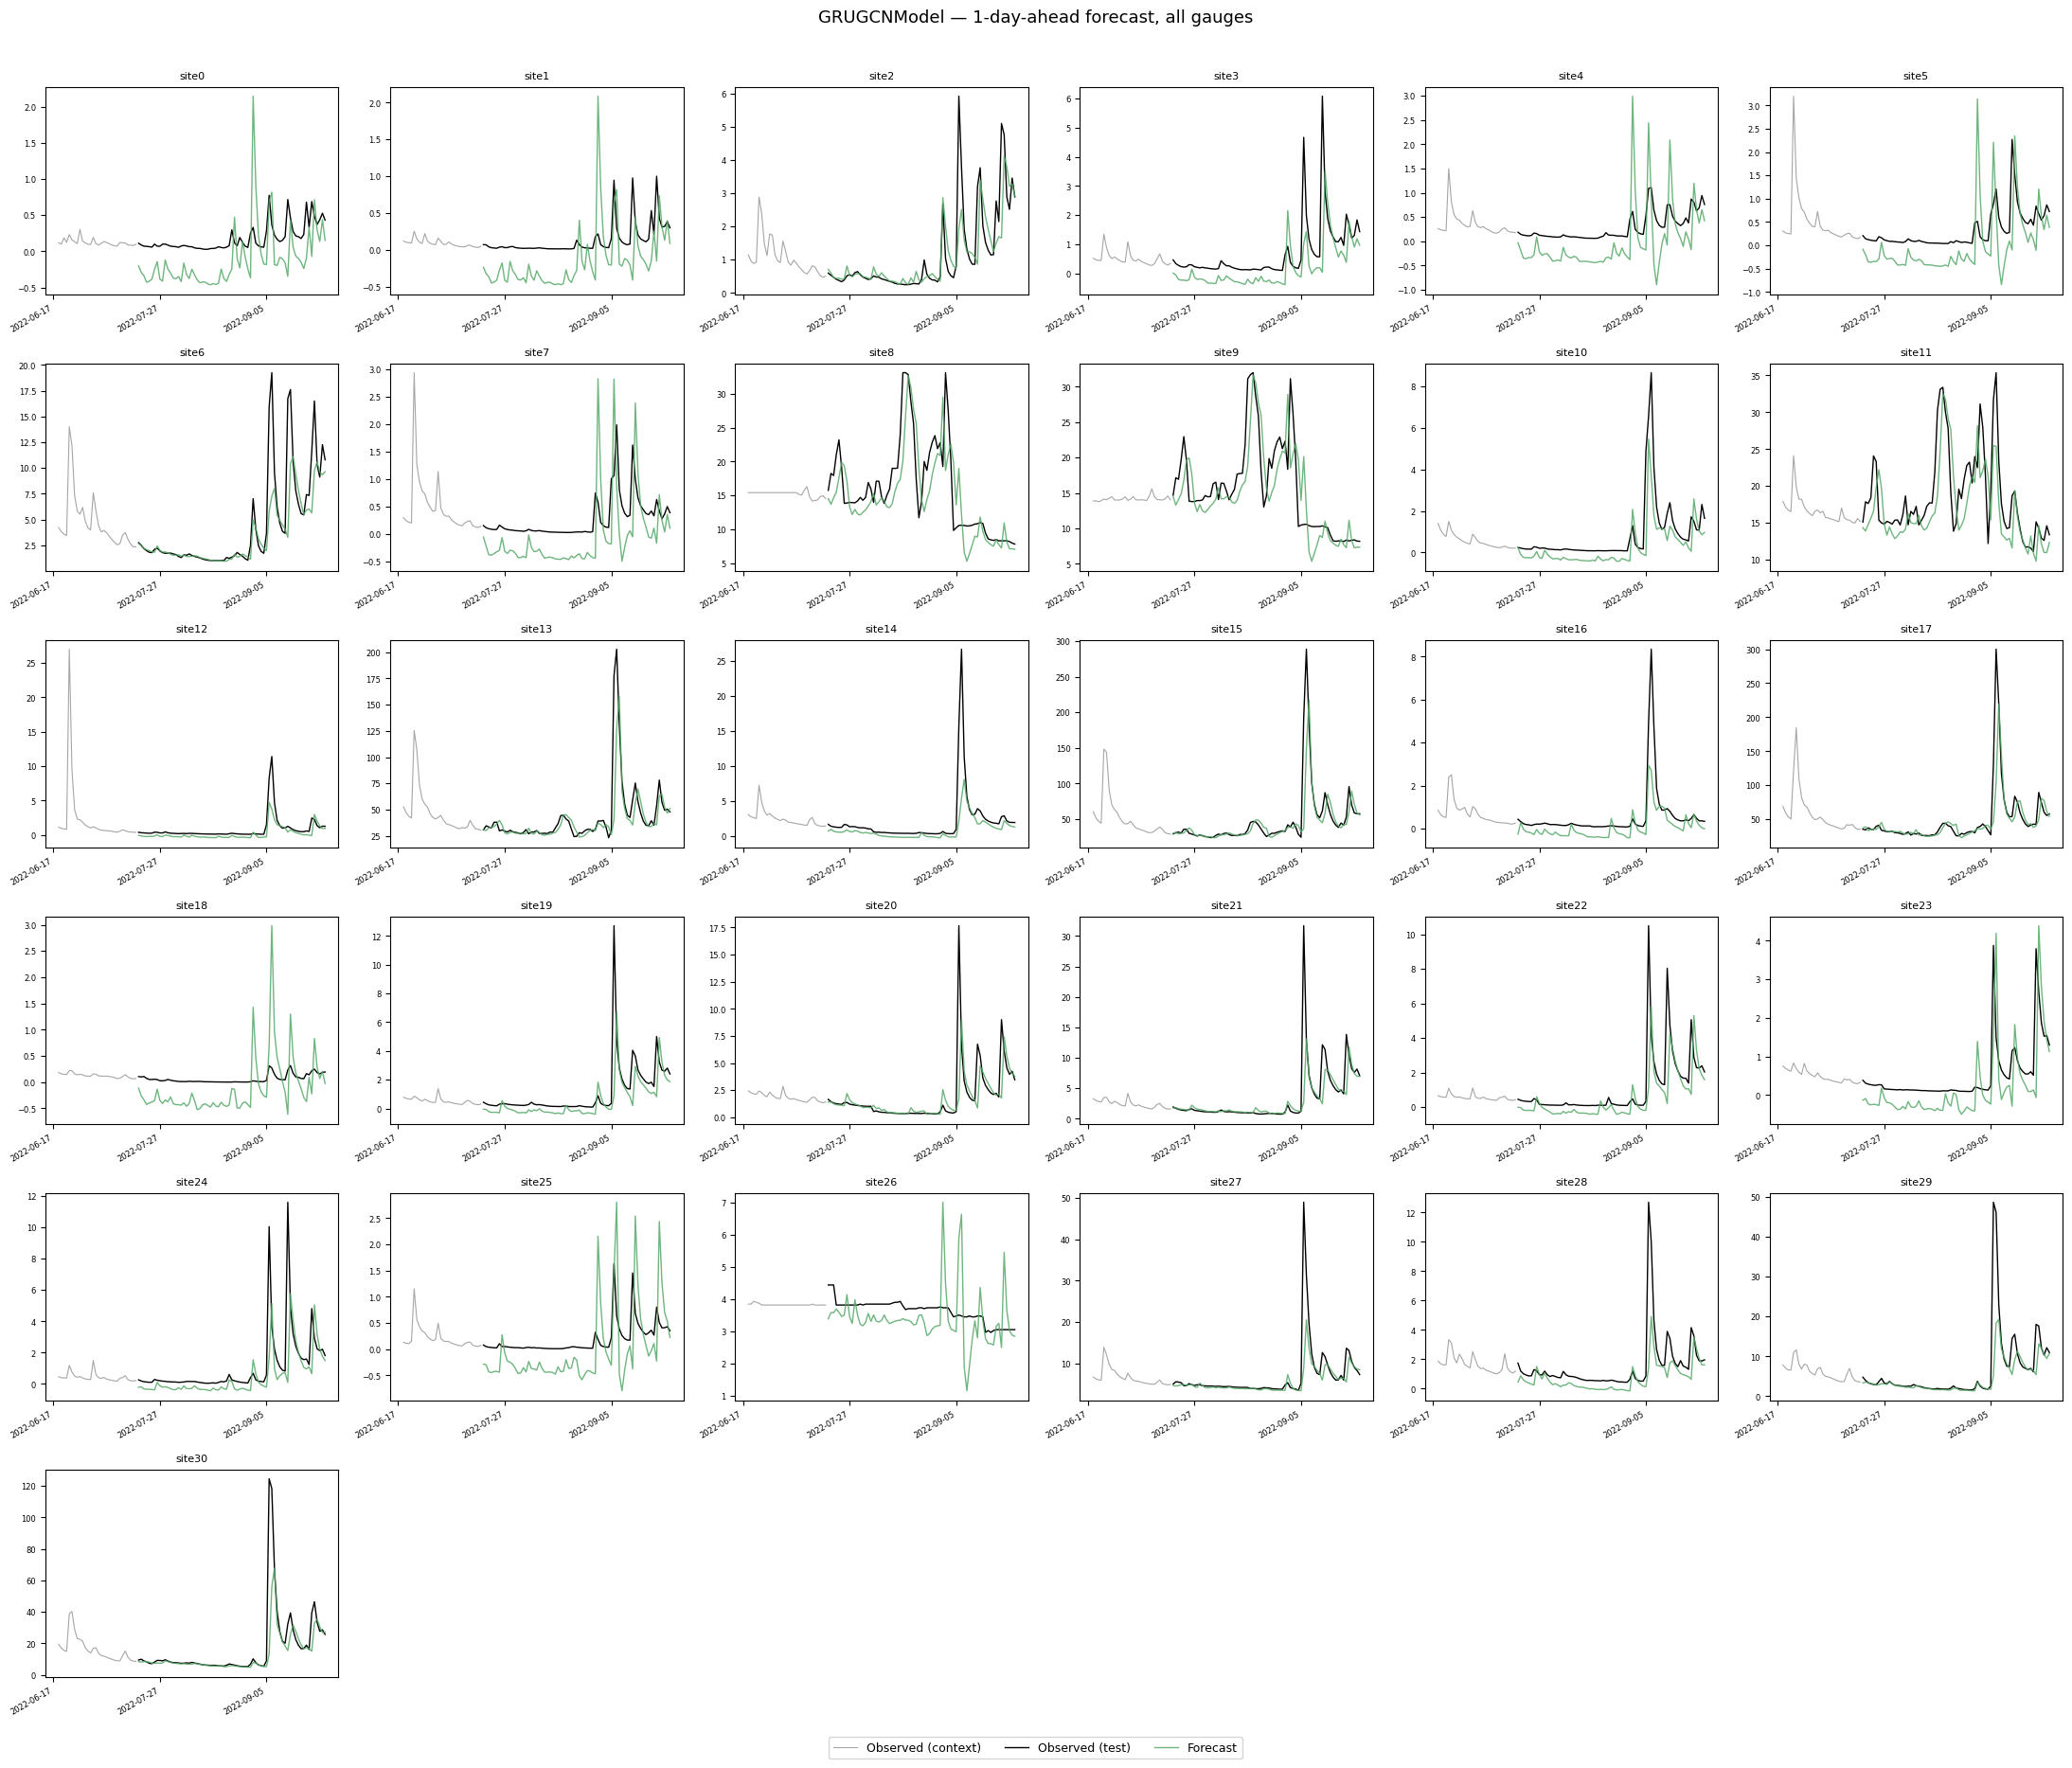

In [16]:
CONTEXT_DAYS = 30   # days of observed history to show before the test period
MODEL_COLORS = {'DCRNN': '#4C72B0', 'GRUGCNModel': '#55A868',
                'GraphWaveNet': '#C44E52', 'TransformerModel': '#8172B2'}

def plot_all_gauges(forecasts_dict, context_days=CONTEXT_DAYS):
    """
    For each model, plot all 31 gauges in a 6×6 grid.
    Shows context_days of observed history + full test period (truth vs forecast).
    """
    node_names = list(target.columns)   # site0 … site30
    ncols, nrows = 6, 6                 # 36 slots, last 5 left blank

    for model_name, fc in forecasts_dict.items():
        dates      = fc['dates']                     # DatetimeIndex, length n_test
        y_true     = fc['y_true']                    # (n_test, N)
        y_hat      = fc['y_hat']                     # (n_test, N)

        # Grab context from the target DataFrame
        test_start = dates[0]
        context_start = test_start - pd.Timedelta(days=context_days)
        context = target.loc[context_start:test_start - pd.Timedelta(days=1)]

        fig, axes = plt.subplots(nrows, ncols, figsize=(22, 18), sharex=False)
        fig.suptitle(f'{model_name} — 1-day-ahead forecast, all gauges', fontsize=13, y=1.01)

        for idx, ax in enumerate(axes.flat):
            if idx >= N_NODES:
                ax.set_visible(False)
                continue

            # Context
            ax.plot(context.index, context.iloc[:, idx],
                    color='grey', lw=0.8, alpha=0.7, label='Observed (context)')
            # Ground truth during test period
            ax.plot(dates, y_true[:, idx],
                    color='black', lw=1.0, label='Observed (test)')
            # Forecast
            ax.plot(dates, y_hat[:, idx],
                    color=MODEL_COLORS[model_name], lw=1.0, alpha=0.85, label='Forecast')

            ax.set_title(node_names[idx], fontsize=8)
            ax.tick_params(labelsize=6)
            ax.xaxis.set_major_locator(plt.MaxNLocator(3))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

        # Shared legend from the last visible axis
        handles, labels = axes.flat[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3,
                   fontsize=9, bbox_to_anchor=(0.5, -0.02))
        plt.tight_layout()
        plt.savefig(f"figures/all_sites_{model_name}_rain_8hop.png", dpi=300)
        plt.show()

plot_all_gauges(all_forecasts)

## 8. Outlet gauge — all models overlaid

site17 (`WEST BRANCH DELAWARE RIVER AT HOBART NY`) is the terminal node of the network
(no outgoing edges). This plot overlays all four model forecasts against the observed record,
with a longer context window to show seasonal patterns.

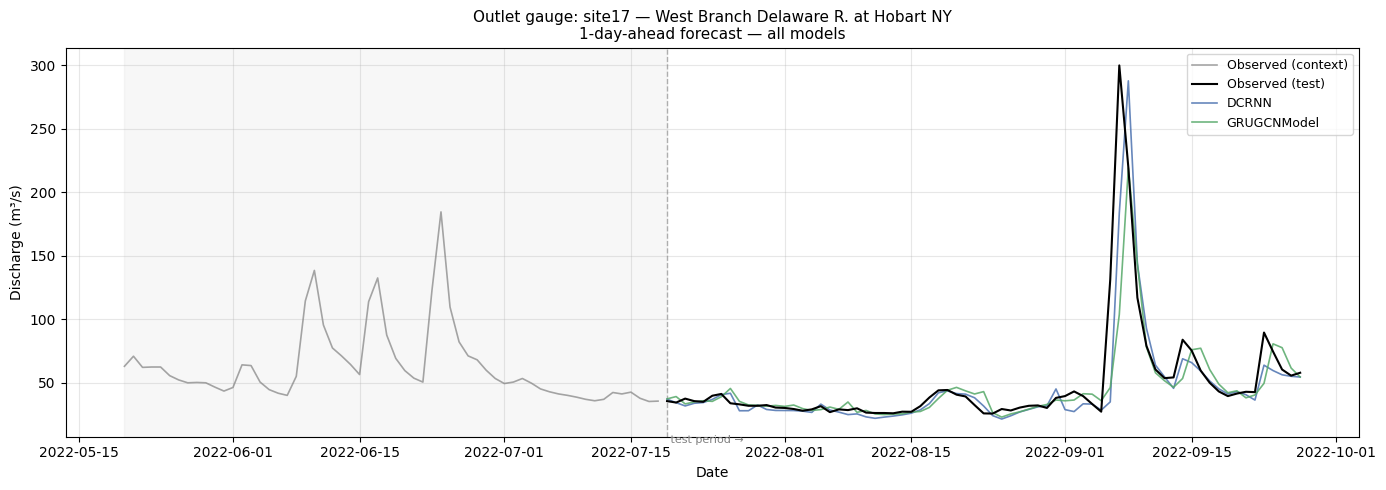

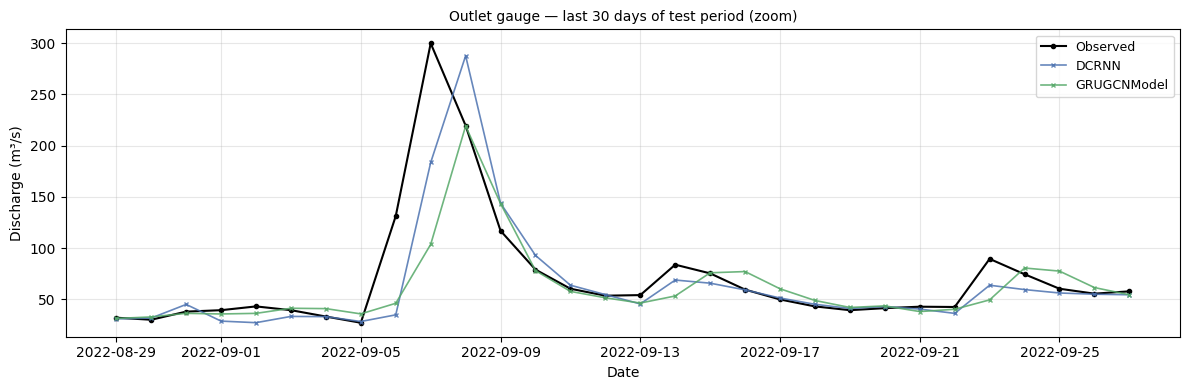

In [17]:
OUTLET_NODE  = 17          # site17 — terminal node (no outgoing edges)
OUTLET_NAME  = 'site17 — West Branch Delaware R. at Hobart NY'
CONTEXT_DAYS_OUTLET = 60   # longer window for the outlet plot

def plot_outlet(forecasts_dict, node_idx=OUTLET_NODE, context_days=CONTEXT_DAYS_OUTLET):
    """
    Single-panel plot of the outlet gauge: all models overlaid.
    Shows context_days of observed history + full test period.
    """
    # Use the first forecast dict to get dates (all models share the same test split)
    first_fc   = next(iter(forecasts_dict.values()))
    dates      = first_fc['dates']
    test_start = dates[0]

    context_start = test_start - pd.Timedelta(days=context_days)
    context = target.loc[context_start:test_start - pd.Timedelta(days=1), f'site{node_idx}']

    fig, ax = plt.subplots(figsize=(14, 5))

    # Shade the context vs test regions
    ax.axvspan(context.index[0], test_start, alpha=0.06, color='grey', label='_context region')
    ax.axvline(test_start, color='grey', lw=1, ls='--', alpha=0.6)
    ax.text(test_start, ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 1,
            ' test period →', fontsize=8, color='grey', va='bottom')

    # Observed — context
    ax.plot(context.index, context.values,
            color='grey', lw=1.2, alpha=0.7, label='Observed (context)')

    # Observed — test period (from first forecast dict)
    ax.plot(dates, first_fc['y_true'][:, node_idx],
            color='black', lw=1.5, label='Observed (test)', zorder=5)

    # Each model forecast
    for model_name, fc in forecasts_dict.items():
        ax.plot(dates, fc['y_hat'][:, node_idx],
                color=MODEL_COLORS[model_name], lw=1.2, alpha=0.85,
                label=f'{model_name}')

    ax.set_title(f'Outlet gauge: {OUTLET_NAME}\n1-day-ahead forecast — all models', fontsize=11)
    ax.set_ylabel('Discharge (m³/s)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/all_forecasts_w_train_rain_8hop.png", dpi=300)
    plt.show()

    # ── Zoom: last 30 days of test period ────────────────────────────────
    zoom_start = dates[-30]
    mask = dates >= zoom_start

    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(dates[mask], first_fc['y_true'][mask, node_idx],
             color='black', lw=1.5, marker='o', ms=3, label='Observed')

    for model_name, fc in forecasts_dict.items():
        ax2.plot(dates[mask], fc['y_hat'][mask, node_idx],
                 color=MODEL_COLORS[model_name], lw=1.2, alpha=0.85,
                 marker='x', ms=3, label=model_name)

    ax2.set_title(f'Outlet gauge — last 30 days of test period (zoom)', fontsize=10)
    ax2.set_ylabel('Discharge (m³/s)')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/all_forecasts_rain_8hop.png", dpi=300)
    plt.show()

plot_outlet(all_forecasts)